# Assignment 1 - Feature Transformation using LDA

Apply Linear Discriminant Analysis on the Iris dataset and classify which species a flower belongs to.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Iris.csv")

# If an 'Id' column exists, drop it
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Separate features (X) and target label (y)
X = df.drop(columns=['Species'])
y = df['Species']
print("Features shape:", X.shape)
print("Unique classes:", y.unique())

Features shape: (150, 4)
Unique classes: <StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# LDA reduces 4 features to 2 components (Number of classes - 1 = 3 - 1 = 2)
lda = LDA(n_components=2)

# Fit on training data and transform
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)
print("Transformed features shape:", X_train_lda.shape)

Transformed features shape: (120, 2)


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict test samples (LDA predicts on the original scaled features)
y_pred = lda.predict(X_test)

# Display results
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 100.0 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



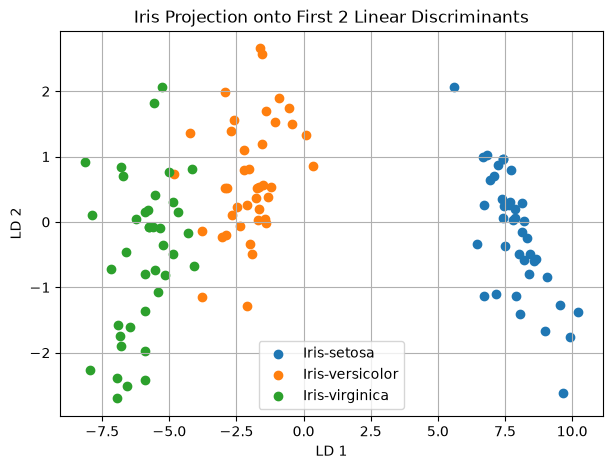

In [5]:
plt.figure(figsize=(7, 5))
for species in y.unique():
    plt.scatter(
        X_train_lda[y_train == species, 0],
        X_train_lda[y_train == species, 1],
        label=species
    )
plt.title("Iris Projection onto First 2 Linear Discriminants")
plt.xlabel("LD 1")
plt.ylabel("LD 2")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Classify a new flower sample
new_flower = pd.DataFrame([[6.0, 2.7, 5.1, 1.6]], columns=X.columns)
print("Predicted species:", lda.predict(scaler.transform(new_flower))[0])

Predicted species: Iris-virginica
